CELL 1 — Install Libraries

In [1]:
!pip install ultralytics roboflow opencv-python numpy matplotlib pandas scipy streamlit openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


CELL 2 — Roboflow Dataset

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")
project = rf.workspace("serhan-0iwep").project("cow-keypoint-e1ozw")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cow-Keypoint-1 in yolov8:: 100%|██████████| 532/532 [00:00<00:00, 4988.44it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


CELL 3 — Training

In [3]:
from ultralytics import YOLO

In [ ]:
model = YOLO("yolov8n-pose.pt")

results = model.train(
    data="/content/Cow-Keypoint-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    verbose=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Cow-Keypoint-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

Saving

In [ ]:
best_path = results.save_dir / "weights" / "best.pt"
print(best_path)

/content/runs/pose/train2/weights/best.pt


In [ ]:
import os
assert os.path.exists(best_path), "Training failed — best model not found"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    best_path,
    "/content/drive/MyDrive/cattle_pose_model/best_v1.pt"
)

'/content/drive/MyDrive/cattle_pose_model/best_v1.pt'

In [5]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/cattle_pose_model/best_v1.pt")

results = model("/content/Cow-Keypoint-1/test/images/img46_png.rf.2e86e475ab1154507340b81bb9ac18f2.jpg")


image 1/1 /content/Cow-Keypoint-1/test/images/img46_png.rf.2e86e475ab1154507340b81bb9ac18f2.jpg: 640x640 1 anton-cow-keypoints, 10.1ms
Speed: 5.2ms preprocess, 10.1ms inference, 44.5ms postprocess per image at shape (1, 3, 640, 640)


CELL 6 — Landmark Demo

Saving img46_png.rf.2e86e475ab1154507340b81bb9ac18f2.jpg to img46_png.rf.2e86e475ab1154507340b81bb9ac18f2.jpg


Text(0.5, 1.0, 'Landmarks')

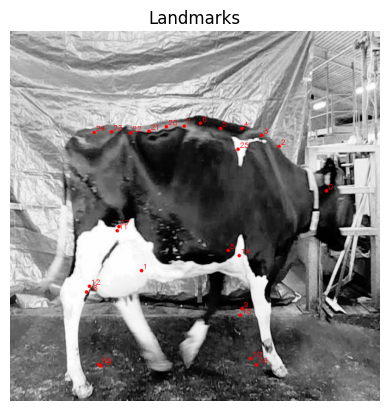

In [6]:
from google.colab import files
import cv2, numpy as np, matplotlib.pyplot as plt

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

results = model(image_path, verbose=False)

img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

res = results[0]
pts = res.keypoints.xy[0].cpu().numpy()

for i,(x,y) in enumerate(pts):
    cv2.circle(img,(int(x),int(y)),3,(255,0,0),-1)
    cv2.putText(img,str(i),(int(x)+3,int(y)-3),
                cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,0,0),1)

plt.imshow(img)
plt.axis("off")
plt.title("Landmarks")

CELL 7 — estimate_cattle()

In [7]:
import numpy as np

# Landmark indices
# 4 = Withers, 5 = Shoulder, 12 = Hip
# 13 = Tailhead, 6/7 = Chest, 15 = Ground

def estimate_cattle(image_path):

    results = model(image_path, verbose=False)

    if len(results[0].keypoints.xy) == 0:
        return None

    pts = results[0].keypoints.xy[0].cpu().numpy()

    def dist(a,b):
        return np.linalg.norm(pts[a] - pts[b])

    OBL = dist(5,12)
    WH  = dist(4,15)
    HL  = dist(12,13)
    HG  = dist(6,7)

    return {
        "OBL": OBL,
        "WH": WH,
        "HL": HL,
        "HG": HG
    }

CELL 8 — compute_ATC()

In [8]:
def compute_ATC(meas):

    if meas is None:
        return None

    OBL = meas["OBL"]
    WH  = meas["WH"]
    HL  = meas["HL"]
    HG  = meas["HG"]

    # prevent division error
    if WH == 0:
        return None

    # ratio-based morphometry (scale invariant)
    r_obl = OBL / WH
    r_hg  = HG / WH
    r_hl  = HL / WH

    # ATC computation
    atc = float(np.mean([r_obl, r_hg, r_hl]))
    atc = round(atc, 3)

    return {
        "ATC_index": atc,
        "BodyLength": r_obl,
        "ChestCapacity": r_hg,
        "RumpLength": r_hl
    }

CELL 9 — Interpretation

In [9]:
def interpret_ATC(score):
    if score < 0.40:
        return "Poor"
    elif score < 0.55:
        return "Below Average"
    elif score < 0.70:
        return "Average"
    elif score < 0.85:
        return "Good"
    else:
        return "Excellent"

CELL 10 — Test Image

In [10]:
img = image_path

meas = estimate_cattle(img)
scores = compute_ATC(meas)

if scores:
    atc = scores["ATC_index"]
    label = interpret_ATC(atc)

    print("ATC:", round(atc,2))
    print("Class:", label)

ATC: 0.54
Class: Below Average


CELL 11 — Dataset Processing

In [11]:
import os
import pandas as pd

folder = "/content/Cow-Keypoint-1/test/images"

rows = []

for f in os.listdir(folder):
    path = os.path.join(folder, f)

    meas = estimate_cattle(path)
    scores = compute_ATC(meas)

    if scores:
        rows.append({
            "image": f,
            "ATC_index": scores["ATC_index"],
            "BodyLength": scores["BodyLength"],
            "ChestCapacity": scores["ChestCapacity"],
            "RumpLength": scores["RumpLength"]
        })

df = pd.DataFrame(rows)
df.to_excel("ATC_results.xlsx", index=False)

print("Saved ATC_results.xlsx")

Saved ATC_results.xlsx


In [12]:
import pandas as pd

df = pd.read_excel("ATC_results.xlsx")
df.head()

,image,ATC_index,BodyLength,ChestCapacity,RumpLength
0,img042_png.rf.33b3f3f7392fcf03ac23a0957b891d27...,0.523,1.054612,0.075660,0.437254
1,img24_png.rf.7a8951d24ce1ade8c9171cf3d94760d5.jpg,0.533,1.085828,0.097132,0.414727
2,img063_png.rf.37a120be5402b9b31eca09ff0dc1199b...,0.522,1.043574,0.094396,0.427716
3,img152_png.rf.885c8d0250159b3c27a17ae6bac34aeb...,0.557,1.111655,0.083724,0.475575
4,img067_png.rf.8ee23defd18326e70f41fd4a57458af7...,0.521,1.055392,0.076274,0.431968


In [ ]:
from google.colab import files
files.download("ATC_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CELL 12 — Plots

Text(0.5, 1.0, 'Trait Scores')

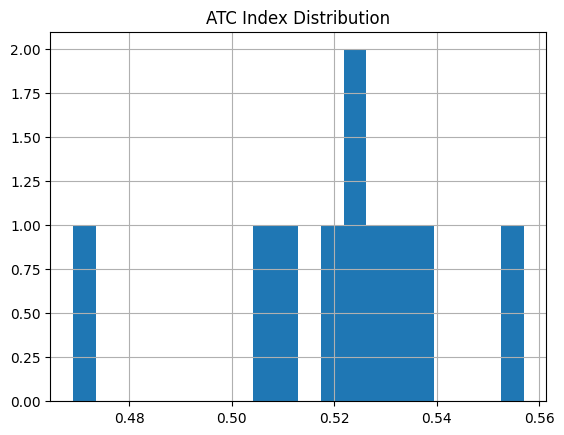

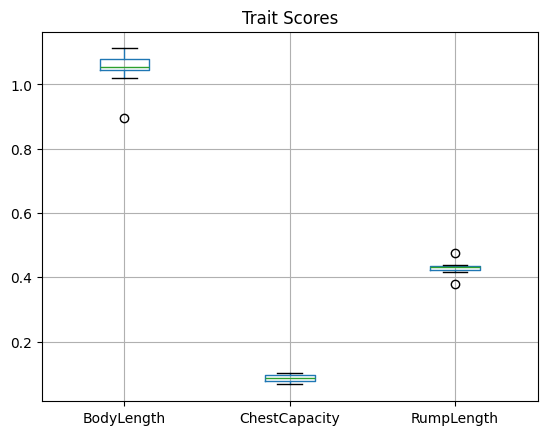

In [13]:
import matplotlib.pyplot as plt

plt.figure()
df["ATC_index"].hist(bins=20)
plt.title("ATC Index Distribution")

plt.figure()
df.boxplot(column=["BodyLength","ChestCapacity","RumpLength"])
plt.title("Trait Scores")

CELL 13 — Evaluation

In [14]:
import numpy as np
import pandas as pd

df = pd.DataFrame(rows)

total = len(os.listdir(folder))
detected = len(df)

det_rate = detected / total

r_obl = df["BodyLength"]
r_hg  = df["ChestCapacity"]
r_hl  = df["RumpLength"]

print("Samples:", len(df))
print("Detection rate:", det_rate)
print("Mean ATC:", df["ATC_index"].mean())
print("Std ATC:", df["ATC_index"].std())
print("Ratio std:", r_obl.std(), r_hg.std(), r_hl.std())
print("Trait correlation:\n", df[["BodyLength","ChestCapacity","RumpLength"]].corr())

Samples: 10
Detection rate: 1.0
Mean ATC: 0.5204000000000001
Std ATC: 0.022858015856344352
Ratio std: 0.06011151894927025 0.011849537491798401 0.02354477532207966
Trait correlation:
                BodyLength  ChestCapacity  RumpLength
BodyLength       1.000000       0.328585    0.095062
ChestCapacity    0.328585       1.000000   -0.517299
RumpLength       0.095062      -0.517299    1.000000


CELL 14 — Gradio App

In [15]:
pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0


In [16]:
import gradio as gr
from ultralytics import YOLO
import numpy as np
import cv2

# ---------- LOAD MODEL ----------
model = YOLO("/content/drive/MyDrive/cattle_pose_model/best.pt")

# ---------- INTERPRETATION ----------
def interpret_ATC(score):
    if score < 0.35: return "Poor"
    elif score < 0.50: return "Below Average"
    elif score < 0.65: return "Average"
    elif score < 0.80: return "Good"
    else: return "Excellent"

# ---------- RECOMMENDATION ----------
def recommend_action(atc):
    if atc < 0.35: return "Immediate intervention needed"
    elif atc < 0.50: return "Improve nutrition & management"
    elif atc < 0.65: return "Acceptable farm standard"
    elif atc < 0.80: return "Good performance – suitable for breeding"
    else: return "Elite genetic class"

# ---------- SUGGESTIONS ----------
def generate_suggestions(atc, r_obl, r_hg, r_hl):
    s = []

    if atc < 0.50:
        s.append("Overall structure weak — improve feeding & health.")
    elif atc < 0.70:
        s.append("Moderate conformation — improvement possible.")
    else:
        s.append("Good structure — maintain management.")

    if r_hg < 0.4:
        s.append("Low chest width → increase protein & minerals.")

    if r_obl < 1.1:
        s.append("Short body length → improve early nutrition.")

    if r_hl < 0.3:
        s.append("Weak rump → monitor reproductive performance.")

    return "\n".join(s)

# ---------- PREPROCESS ----------
def preprocess(img):
    h, w = img.shape[:2]
    scale = 640 / max(h, w)
    if scale < 1:
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
    return img

# ---------- MAIN PIPELINE ----------
def analyze(img):

    if img is None:
        return None, 0, "", "", ""

    img = preprocess(img)

    res = model(img, verbose=False)

    if len(res[0].keypoints.xy) == 0:
        return None, 0, "No cow detected", "", "If keypoints are not detected, the image is skipped , to avoid incorrect morphometric estimation"

    pts = res[0].keypoints.xy[0].cpu().numpy()

    def d(a,b): return np.linalg.norm(pts[a] - pts[b])

    # --- measurements ---
    OBL = d(5,12)
    WH  = d(4,15)
    HL  = d(12,13)
    HG  = d(6,7)

    # --- ratios ---
    r_obl = OBL / WH
    r_hg  = HG / WH
    r_hl  = HL / WH

    # --- ATC ---
    atc = float(np.mean([r_obl, r_hg, r_hl]))

    # ---------- VISUALIZATION ----------
    vis = img.copy()
    for (x,y) in pts:
        cv2.circle(vis, (int(x), int(y)), 3, (0,255,0), -1)

    return (
        vis,
        round(atc, 2),
        interpret_ATC(atc),
        recommend_action(atc),
        generate_suggestions(atc, r_obl, r_hg, r_hl)
    )

# ---------- UI ----------
demo = gr.Interface(
    fn=analyze,
    inputs=gr.Image(type="numpy"),
    outputs=[
        gr.Image(label="Detected Landmarks", height=300),
        gr.Number(label="ATC Score"),
        gr.Text(label="Conformation", lines=2),
        gr.Text(label="Recommendation", lines=2),
        gr.Textbox(label="Suggestions", lines=5)
    ],
    title="IMAGE BASED CATTLE MEASUREMENT AND TRAIT ESTIMATION SYSTEM ",
    description="Upload a cow image to evaluate structural conformation and receive actionable recommendations."
)

demo.launch(share=True , debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d7e1305b67a1f52dd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
import os
print(os.listdir())

['.config', '.gradio', 'ATC_results.xlsx', 'drive', 'img46_png.rf.2e86e475ab1154507340b81bb9ac18f2.jpg', 'Cow-Keypoint-1', 'sample_data']


Data Split Check

In [18]:
import os

base_path = "Cow-Keypoint-1"
splits = ["train", "valid", "test"]

total_all = 0
counts = {}

# count images
for split in splits:
    path = os.path.join(base_path, split, "images")
    count = len(os.listdir(path))
    counts[split] = count
    total_all += count

# print results
for split in splits:
    count = counts[split]
    print(f"\n===== {split.upper()} SPLIT =====")
    print(f"Images : {count} ({count/total_all:.2%})")


===== TRAIN SPLIT =====
Images : 240 (92.31%)

===== VALID SPLIT =====
Images : 10 (3.85%)

===== TEST SPLIT =====
Images : 10 (3.85%)
